IMPORT LIBRARIES

In [8]:
# =========================
# DATA STACK BÁSICO
# =========================
import numpy as np
import pandas as pd

# =========================
# VISUALIZACIÓN
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CONFIGURACIÓN VISUAL
# =========================
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

# =========================
# UTILIDADES
# =========================
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display



EXTRACCIÓN DE DATOS DEL CSV 


📊 DATA OVERVIEW
Shape: (10000, 14)




,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



🧠 INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None


📉 MISSING VALUES


Series([], dtype: int64)


📊 NUMERICAL STATS


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48



📌 DUPLICATES
0

📊 HISTOGRAMS


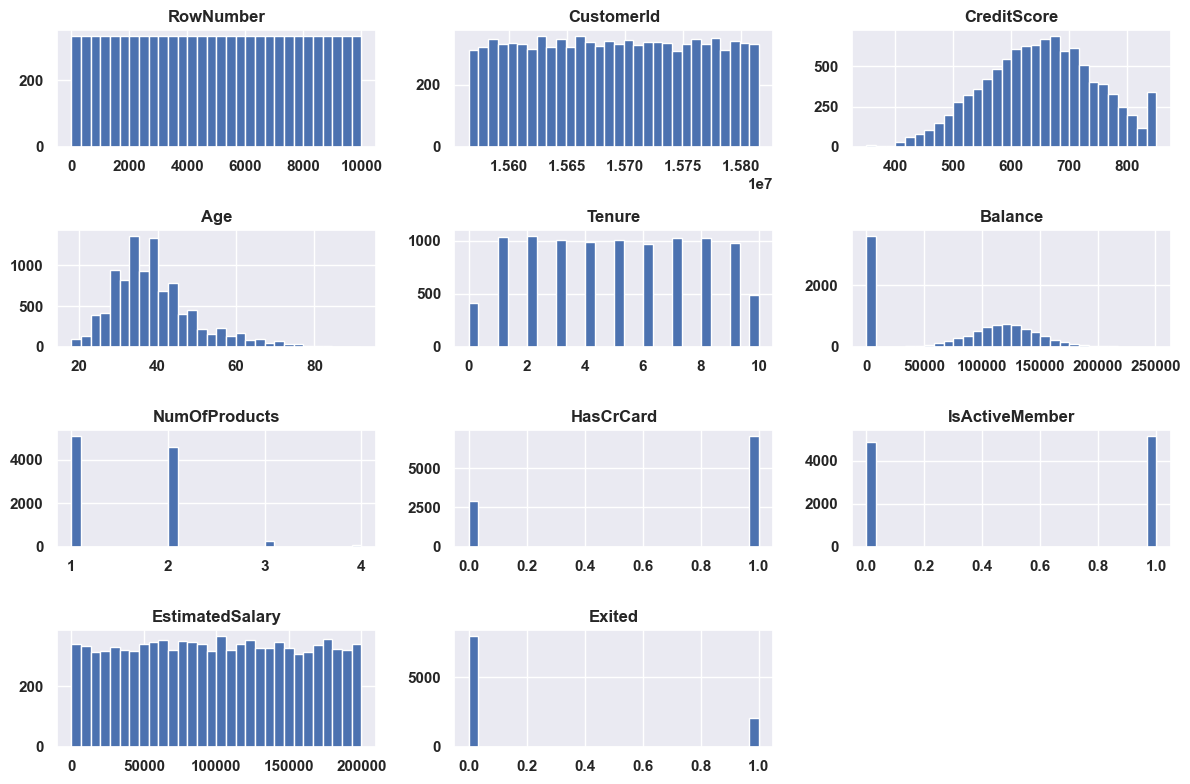


🔥 CORRELATION HEATMAP


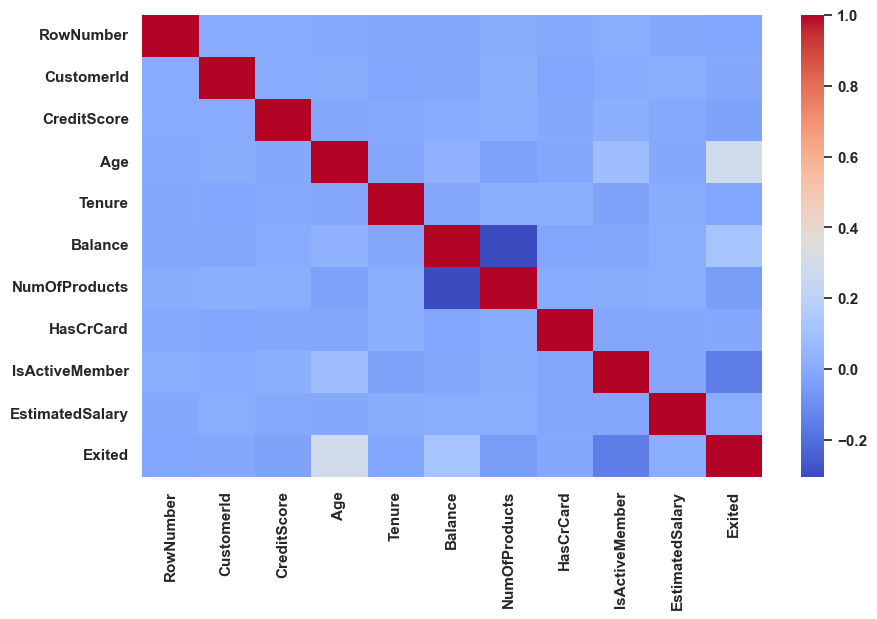

In [ ]:
df=pd.read_csv("Churn_Modelling.csv")

def data_descriptor(df):
    print("\n====================")
    print("📊 DATA OVERVIEW")
    print("====================")
    print(f"Shape: {df.shape}")
    print("\n")

    display(df.head())

    print("\n====================")
    print("🧠 INFO")
    print("====================")
    display(df.info())

    print("\n====================")
    print("📉 MISSING VALUES")
    print("====================")
    missing = df.isnull().sum().sort_values(ascending=False)
    display(missing[missing > 0])

    print("\n====================")
    print("📊 NUMERICAL STATS")
    print("====================")
    display(df.describe().T)

    print("\n====================")
    print("📌 DUPLICATES")
    print("====================")
    print(df.duplicated().sum())

    # =====================
    # VISUALS
    # =====================

    num_cols = df.select_dtypes(include="number").columns

    if len(num_cols) > 0:
        print("\n📊 HISTOGRAMS")
        df[num_cols].hist(figsize=(12, 8), bins=30)
        plt.tight_layout()
        plt.show()

        print("\n🔥 CORRELATION HEATMAP")
        plt.figure(figsize=(10,6))
        sns.heatmap(df[num_cols].corr(), cmap="coolwarm", annot=False)
        plt.show()
data_descriptor(df)

The data has been explored correctly and no missing values have been found
Extract important columns



📊 DATA OVERVIEW
Shape: (10000, 11)




,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



🧠 INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


None


📉 MISSING VALUES


Series([], dtype: int64)


📊 NUMERICAL STATS


,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00



📌 DUPLICATES
0

📊 HISTOGRAMS


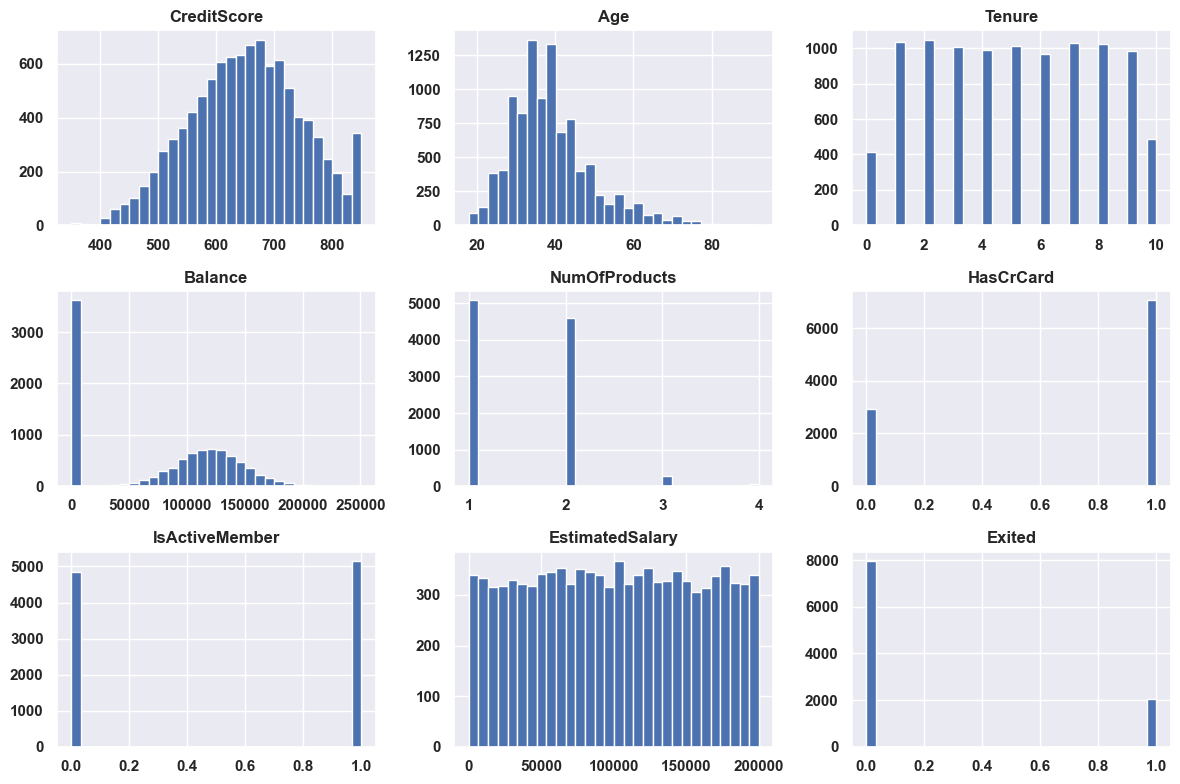


🔥 CORRELATION HEATMAP


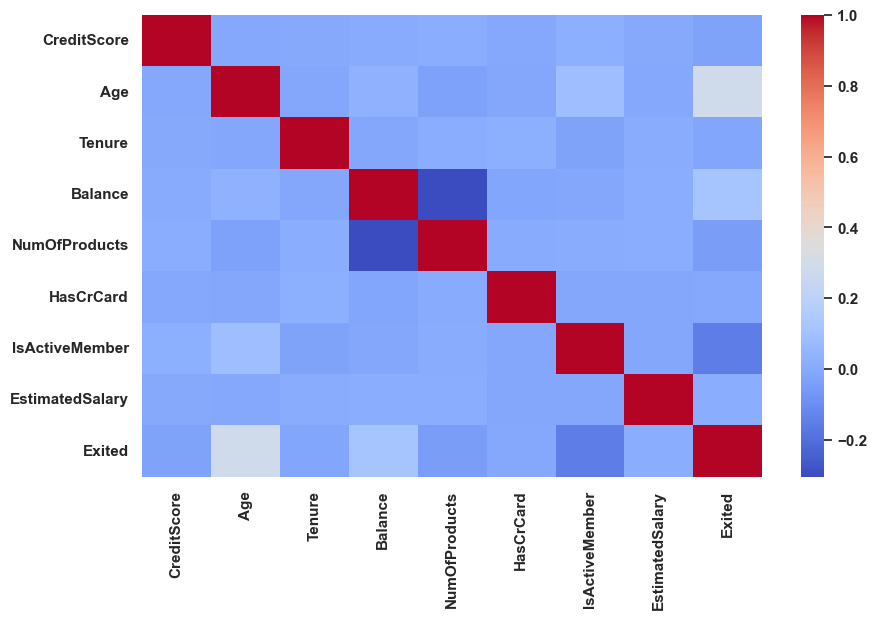

In [25]:
# Seleccionar columnas importantes (features + target)
columnas_importantes = [
    'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
    'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary', 'Exited'
]

# Crear nuevo DataFrame solo con esas columnas
df_clean = df[columnas_importantes]
data_descriptor(df_clean)

Veryfy how much data negative and positive we have on Exited variable

In [42]:

abandonaron = df_clean[df_clean['Exited'] == False]

siguieron= df_clean[df_clean['Exited'] == True]

display(abandonaron.shape)
display(siguieron.shape)




(7963, 11)

(2037, 11)

##Multilayer perceptron (MLP) desing

In [43]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

ModuleNotFoundError: No module named 'tensorflow'